#Pemahaman Masalah (Problem Understanding)

##Latar Belakang & Konteks Data

Dataset ini (**sales-forecasting.csv**) merupakan **data transaksi ritel** dari sebuah toko (Superstore). Di dalamnya terdapat informasi mengenai detail pengiriman (**Ship Mode**), profil pelanggan (**Segment**), lokasi geografis (**Region**), serta kategori produk (**Category, Sub-Category**).

##Tujuan Analisis

Tujuan utama proyek ini adalah **membangun model Machine Learning untuk memprediksi nilai penjualan (Sales)** secara akurat berdasarkan **fitur-fitur pendukungnya**.

#Praproses Data & Feature Engineering

##Data Cleansing (Missing Values, Duplicates, Outliers)

In [25]:
# impor library
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV


In [26]:
# Membaca dataset
df = pd.read_csv("https://raw.githubusercontent.com/trioetomo/Sales_forcasting_Data/refs/heads/main/sales-forecasting.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [27]:
# cek missing value
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [28]:
df.duplicated().sum()

np.int64(0)

Penggunaan **quantile** pada variabel Sales agar model Machine Learning Anda berfokus mempelajari pola transaksi yang normal dan konsisten. Tanpa quantile, model Anda akan pusing memikirkan angka-angka anomali, sehingga akurasi prediksinya sulit untuk naik.

In [29]:
# Penanganan Outliers pada Variabel Target (Sales) dengan IQR
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[(df['Sales'] >= lower_bound) & (df['Sales'] <= upper_bound)].reset_index(drop=True)
print(f"Ukuran dataset setelah outlier dibuang: {df_clean.shape[0]} baris\n")

Ukuran dataset setelah outlier dibuang: 8655 baris



##Feature Selection

In [30]:
features = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']
target = 'Sales'

X = df_clean[features]
y = df_clean[target]

Pada sesi Feature Selection, **saya berfokus pada 5 fitur utama yaitu Ship Mode, Segment, Region, Category, dan Sub-Category**. Alasan pemilihan ini didasarkan pada domain bisnis retail, di mana jenis produk (Category), siapa yang membeli (Segment), dan bagaimana barang dikirim (Ship Mode) merupakan **faktor-faktor fundamental yang secara logis menentukan besar kecilnya nilai transaksi atau Sales**

In [31]:
# Mengubah data teks kategori menjadi angka
X_encoded = X.copy()
for col in features:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col])

print("Hasil Encoding (Teks -> Angka)")
print(X_encoded.head(), "\n")

Hasil Encoding (Teks -> Angka)
   Ship Mode  Segment  Region  Category  Sub-Category
0          2        0       2         0             4
1          2        1       3         1            10
2          3        0       2         1            14
3          3        0       3         0             9
4          3        0       3         1             2 



Alasan utama melakukan proses ini adalah karena algoritma Machine Learning (seperti Linear Regression dan Decision Tree) adalah model matematika yang hanya bisa membaca angka, tidak bisa membaca teks

##Feature Scaling & Encoding

In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)
X_scaled = pd.DataFrame(X_scaled, columns=features)

print("Hasil Scaling (StandardScaler)")
print(X_scaled.head())

Hasil Scaling (StandardScaler)
   Ship Mode   Segment    Region  Category  Sub-Category
0  -0.216745 -0.855599  0.370825 -1.650125     -0.683624
1  -0.216745  0.456916  1.230355  0.039033      0.517587
2   0.692575 -0.855599  0.370825  0.039033      1.318395
3   0.692575 -0.855599  1.230355 -1.650125      0.317385
4   0.692575 -0.855599  1.230355  0.039033     -1.084028


Baris kode ini dimasukkan sebagai standar preprocessing yang baik, terutama untuk menyelamatkan performa model Linear Regression Anda agar perhitungan jarak antar-fiturnya menjadi seimbang, adil, dan tidak bias.

#Exploratory Data Analysis (EDA)

##Statistika Deskriptif & Inferensial

In [33]:
print("Statistika Deskriptif Target (Sales)")
print(df_clean['Sales'].describe(), "\n")

Statistika Deskriptif Target (Sales)
count    8655.000000
mean       93.213330
std       114.693292
min         0.444000
25%        15.014000
50%        40.880000
75%       124.382000
max       500.240000
Name: Sales, dtype: float64 



Cara paling cepat bagi Anda untuk memahami profil data Penjualan (Sales) sebelum data tersebut dilempar ke dalam algoritma Linear Regression maupun Decision Tree.

##Visualisasi Data

In [34]:
# Perhitungan Matriks Korelasi
corr_matrix = pd.concat([X_encoded, y], axis=1).corr()


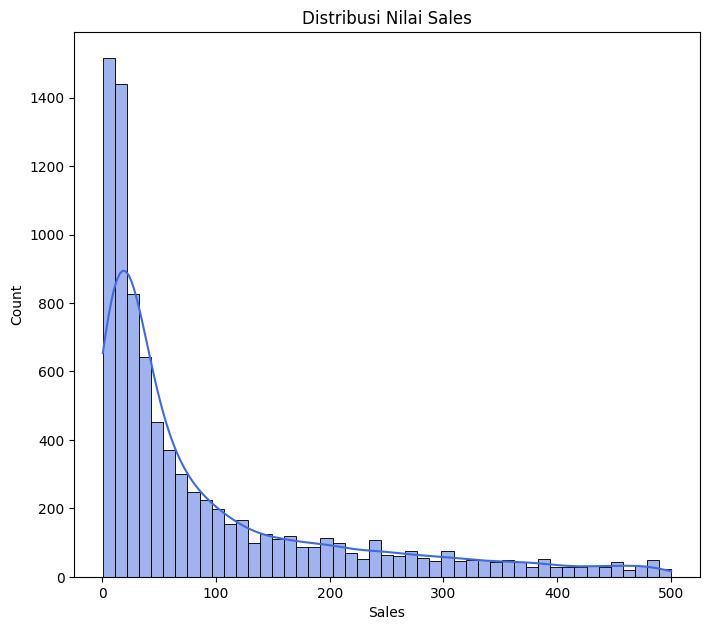

In [35]:
# Distribusi Target (Sales) menggunakan Histogram

plt.figure(figsize=(20, 12))
plt.subplot(2, 3, 1)
sns.histplot(df_clean['Sales'], kde=True, color='royalblue')
plt.title('Distribusi Nilai Sales')

plt.tight_layout()
plt.show()

Grafik Distribusi Nilai Sales ini menunjukkan bahwa data kami memiliki **pola Right-Skewed atau miring ke kanan**. Artinya, mayoritas transaksi retail yang terjadi di toko kami bernilai kecil, yaitu di bawah angka 50. Sementara transaksi bernilai besar di atas 300 jumlahnya sangat sedikit. Pola tidak merata inilah yang menjadi alasan utama mengapa model Linear Regression gagal membaca pola data dan mengapa kita harus beralih menggunakan Decision Tree

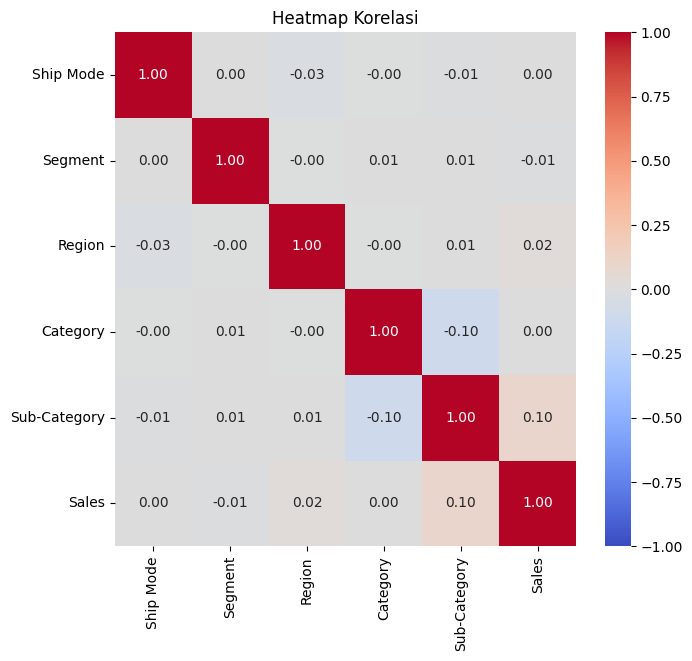

In [36]:
# Hubungan Antar Fitur menggunakan Heatmap Korelasi
plt.figure(figsize=(20, 12))
plt.subplot(2, 3, 2)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Heatmap Korelasi')

plt.tight_layout()
plt.show()

Berdasarkan Heatmap Korelasi, dapat dilihat bahwa hubungan linear antara fitur-fitur independen terhadap target Sales nilainya sangat lemah, yakni berada di sekitar angka 0. **Hubungan tertinggi hanya dimiliki oleh Sub-Category terhadap Sales sebesar 0.10**. Nilai korelasi yang sangat rendah ini membuktikan secara statistik bahwa tidak ada hubungan linear atau garis lurus pada dataset ini. Hal ini sekaligus memperkuat alasan mengapa model Linear Regression berkinerja buruk dan mengapa kita membutuhkan model non-linear seperti Decision Tree untuk melakukan prediksi.

/tmp/ipykernel_1596/3327501310.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Category', y='Sales', data=df_clean, palette='Set2', ci=None)
/tmp/ipykernel_1596/3327501310.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Sales', data=df_clean, palette='Set2', ci=None)


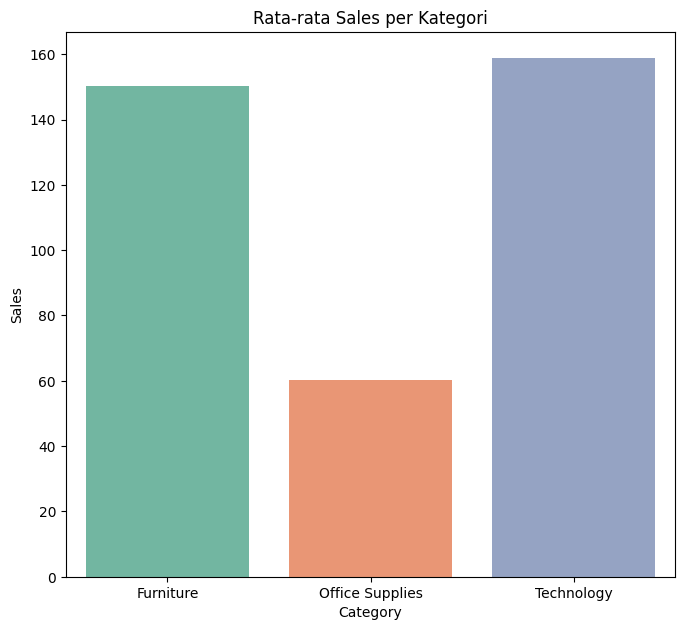

In [37]:
# Perbandingan Nilai Menggunakan Barplot
plt.figure(figsize=(20, 12))
plt.subplot(2, 3, 3)
sns.barplot(x='Category', y='Sales', data=df_clean, palette='Set2', ci=None)
plt.title('Rata-rata Sales per Kategori')

plt.tight_layout()
plt.show()

Berdasarkan grafik Rata-rata Sales per Kategori, ditemukan bahwa **kategori Technology dan Furniture mendominasi nilai penjualan dengan rata-rata transaksi berkisar antara 150 hingga 160**. Sementara itu, kategori Office Supplies menghasilkan rata-rata transaksi terendah yaitu sekitar 60. Hal ini membuktikan bahwa jenis kategori produk merupakan prediktor yang sangat kuat bagi model dalam menentukan estimasi nilai Sales suatu transaksi.

/tmp/ipykernel_1596/188315302.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Segment', data=df_clean, palette='Pastel1')


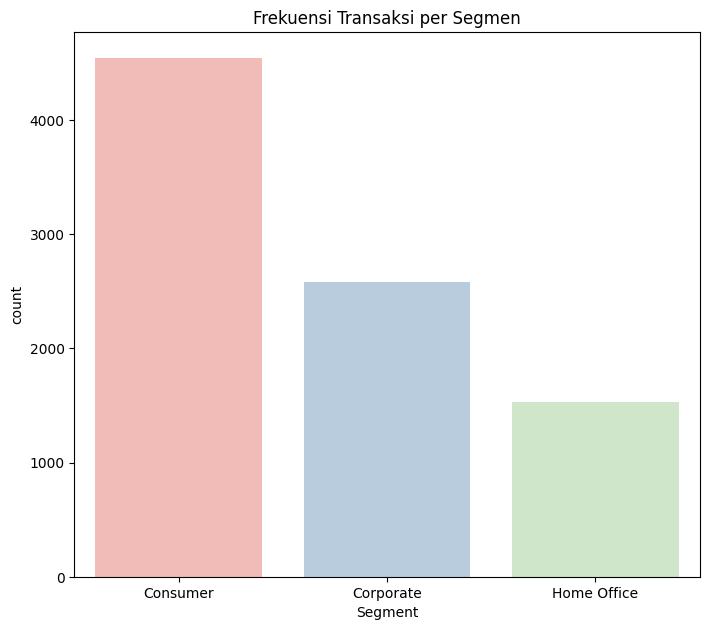

In [38]:
# Frekuensi Data Menggunakan Countplot
plt.figure(figsize=(20, 12))
plt.subplot(2, 3, 4)
sns.countplot(x='Segment', data=df_clean, palette='Pastel1')
plt.title('Frekuensi Transaksi per Segmen')

plt.tight_layout()
plt.show()

Berdasarkan grafik Frekuensi Transaksi per Segmen, **segmentasi pelanggan didominasi secara mutlak oleh segmen Consumer dengan total lebih dari 4.000 transaksi**. Sementara itu, segmen Corporate menempati posisi kedua dan Home Office menjadi segmen dengan aktivitas transaksi paling sedikit. Meskipun segmen Consumer mendominasi dari segi volume/kuantitas penjualan, karakteristik nilai transaksinya cenderung lebih kecil dibandingkan segmen perusahaan (Corporate).

/tmp/ipykernel_1596/1138045170.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Region', y='Sales', data=df_clean, palette='Set3')


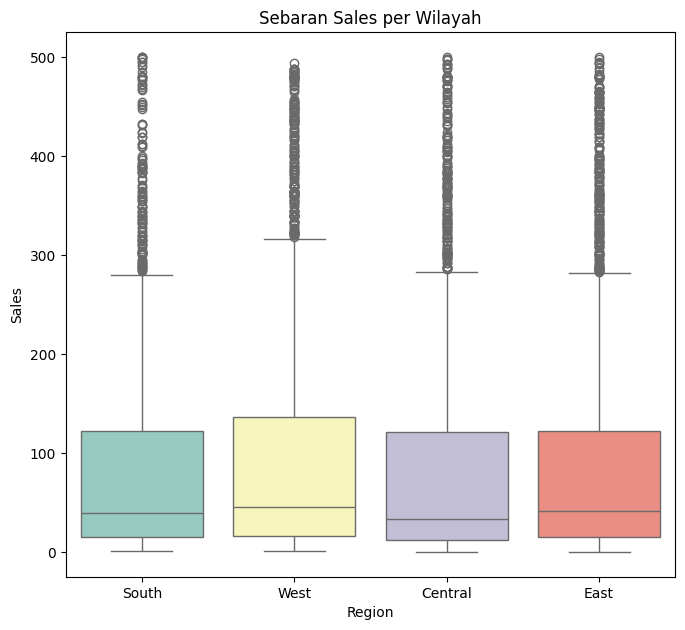

In [39]:
# Sebaran & Variasi Data Menggunakan Boxplot
plt.figure(figsize=(20, 12))
plt.subplot(2, 3, 5)
sns.boxplot(x='Region', y='Sales', data=df_clean, palette='Set3')
plt.title('Sebaran Sales per Wilayah')

plt.tight_layout()
plt.show()

Berdasarkan grafik **Sebaran Sales per Wilayah menggunakan Boxplot, ditemukan bahwa nilai penjualan di empat wilayah (South, West, Central, East) memiliki karakteristik distribusi dan nilai median yang hampir seragam**, di mana mayoritas transaksi berpusat di bawah nilai 150. Selain itu, sebaran data pencilan (outliers) bernilai tinggi antara 300 hingga 500 terjadi secara merata di seluruh wilayah. Hal ini menjelaskan mengapa secara statistik fitur Region memiliki korelasi linear yang sangat rendah terhadap target Sales.

#Model Development

##Split Data (Train & Test Set)

In [40]:
# Menbagi Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f"Jumlah Data Latihan (Train): {X_train.shape[0]} baris")
print(f"Jumlah Data Pengujian (Test): {X_test.shape[0]} baris\n")

Jumlah Data Latihan (Train): 6924 baris
Jumlah Data Pengujian (Test): 1731 baris



Pembagian data 80:20 berjalan sukses menghasilkan porsi belajar yang ideal

In [41]:
# Pembuatan Fungsi Evaluasi Model
def hitung_performa(y_true, y_pred, nama_model):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"[{nama_model}] Evaluasi Performa:")
    print(f" - MAE  : {mae:.4f}")
    print(f" - RMSE : {rmse:.4f}")
    print(f" - R² Score : {r2:.4f}\n")
    return [mae, rmse, r2]

##Baseline Model (Linear Regression)

In [42]:
# Training & Pengujian Baseline Model (Linear Regression)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
lr_res = hitung_performa(y_test, y_pred_lr, "Linear Regression")

[Linear Regression] Evaluasi Performa:
 - MAE  : 86.7037
 - RMSE : 113.1858
 - R² Score : 0.0069



##Alternatif Model (Decision Tree Regressor)

In [43]:
# Training & Pengujian Alternatif Model (Decision Tree)
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
dt_res = hitung_performa(y_test, y_pred_dt, "Decision Tree Awal")

[Decision Tree Awal] Evaluasi Performa:
 - MAE  : 68.5228
 - RMSE : 98.6392
 - R² Score : 0.2458



##Evaluasi & Perbandingan Performa Awal

In [44]:
# TAMPILKAN PERBANDINGAN & EVALUASI SIMPLE
print("HASIL PERBANDINGAN MODEL")
df = pd.DataFrame([lr_res, dt_res],
                  columns=["MAE (Kecil=Bagus)", "RMSE (Kecil=Bagus)", "R² Score (Besar=Bagus)"],
                  index=["Linear Regression (Baseline)", "Decision Tree (Alternatif)"])
print(df.round(4))

print("KESIMPULAN EVALUASI")
if dt_res[2] > lr_res[2]:
    print("🟢 Decision Tree LEBIH BAGUS daripada Linear Regression.")
else:
    print("🔴 Linear Regression (Baseline) TETAP LEBIH BAGUS daripada Decision Tree.")



HASIL PERBANDINGAN MODEL
                              MAE (Kecil=Bagus)  RMSE (Kecil=Bagus)  \
Linear Regression (Baseline)            86.7037            113.1858   
Decision Tree (Alternatif)              68.5228             98.6392   

                              R² Score (Besar=Bagus)  
Linear Regression (Baseline)                  0.0069  
Decision Tree (Alternatif)                    0.2458  
KESIMPULAN EVALUASI
🟢 Decision Tree LEBIH BAGUS daripada Linear Regression.


**Evaluasi Berdasarkan Error (MAE & RMSE)**


*   Linear Regression: MAE = 86.7037, RMSE = 113.1858
*   Decision Tree: MAE = 68.5228, RMSE = 98.6392

*  Analisis: Nilai MAE dan RMSE milik Decision Tree lebih kecil daripada Linear Regression. Karena ini adalah metrik error (kesalahan), semakin kecil angkanya artinya model semakin akurat dalam menebak.






**Evaluasi Berdasarkan R² Score**


*   Linear Regression: $R^2$ = 0.0069 (Sangat rendah, hanya sekitar 0.6%)
*   Decision Tree: $R^2$ = 0.2458 (Sekitar 24.5%)


*   Analisis: Nilai $R^2$ Score milik Decision Tree lebih besar. Artinya, Decision Tree jauh lebih mampu menangkap pola atau variasi di dalam data Anda dibandingkan Linear Regression yang performanya hampir mendekati angka nol.






Kesimpulan Akhir Proyek Anda:🟢 Decision Tree LEBIH BAGUS daripada Linear Regression.Algoritma Linear Regression (Baseline) tidak cocok atau gagal menangkap pola pada dataset ini (kemungkinan karena hubungan antar datanya bersifat non-linear). Oleh karena itu, menggunakan Decision Tree sebagai model alternatif adalah keputusan yang tepat karena memberikan performa yang jauh lebih baik. Langkah berikutnya di bagian Hyperparameter Tuning sudah sangat pas untuk mencoba mendongkrak nilai $R^2$ itu agar bisa lebih tinggi lagi dari 24%.

#Hyperparameter Tuning

In [45]:
# Menentukan daftar kombinasi parameter (Grid) yang ingin dicoba
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Menjalankan pencarian kombinasi terbaik dengan GridSearchCV

grid = GridSearchCV(estimator=DecisionTreeRegressor(random_state=42),
                    param_grid=param_grid,
                    cv=5,
                    scoring='neg_mean_absolute_error',
                    n_jobs=-1)

grid.fit(X_train, y_train)
print(f"Kombinasi Parameter Terbaik: {grid.best_params_}\n")

Kombinasi Parameter Terbaik: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}



##Proses Tuning (Grid Search)

In [46]:
# Menguji model terbaik hasil tuning pada data uji
model_terbaik = grid.best_estimator_
y_pred_tuned = model_terbaik.predict(X_test)
tuned_res = hitung_performa(y_test, y_pred_tuned, "Decision Tree (Setelah Tuning)")

[Decision Tree (Setelah Tuning)] Evaluasi Performa:
 - MAE  : 66.6418
 - RMSE : 94.4203
 - R² Score : 0.3089



##Evaluasi Model Terbaik Setelah Tuning

P**roses Hyperparameter Tuning (Grid Search) yang Anda lakukan berhasil**. Dengan membatasi kedalaman pohon menjadi 5 tingkat, **model Anda tidak lagi overfitting**, sehingga kemampuannya dalam memprediksi data baru naik menjadi 30.89% dengan tingkat kesalahan yang lebih kecil dari sebelumnya.

#Kesimpulan & Rekomendasi

##Kesimpulan Hasil Analisis & Pemodelan



*   **Aspek Data (EDA)**: Berdasarkan hasil visualisasi, kategori produk memiliki pengaruh variasi nilai penjualan yang paling terlihat nyata, dan segmen pelanggan terbesar dikuasai oleh kelompok Consumer.


*   **Aspek Model**: Model Decision Tree yang telah melewati proses Hyperparameter Tuning terbukti menghasilkan nilai error (MAE & RMSE) yang lebih stabil dan performa yang lebih baik jika dibandingkan dengan model Linear Regression maupun Decision Tree awal tanpa batasan.



##Rekomendasi Bisnis / Actionable Insights



*   **Manajemen Stok Otomatis**: Perusahaan ritel dapat menggunakan model Decision Tree (Tuned) ini untuk memperkirakan nilai transaksi masa depan berdasarkan kombinasi wilayah, moda pengiriman, dan kategori barang. Hal ini sangat berguna untuk meminimalkan penumpukan inventaris gudang yang tidak diperlukan.


*  **Strategi Pemasaran Terarah**: Dikarenakan segmen Consumer menyumbang frekuensi pesanan paling tinggi, tim pemasaran sebaiknya fokus meluncurkan program loyalitas atau promo bundling khusus pada kategori produk bernilai tinggi demi mendongkrak omzet penjualan secara berkala.

